In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
df = pd.read_excel('/content/drive/MyDrive/yahoo_data.xlsx', )

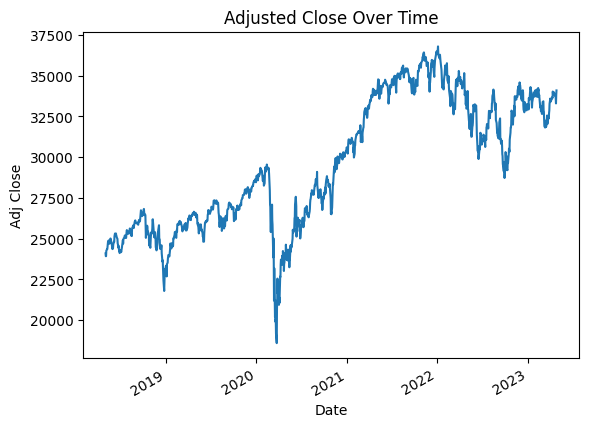

Step 1 done.


In [40]:
# === Bandara N.H.M.W.W.D.S: Date Conversion & Sorting ===
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

# Visualization
df['Adj Close**'].plot(title="Adjusted Close Over Time")
plt.xlabel("Date"); plt.ylabel("Adj Close")
plt.show()
print("Step 1 done.")


Outliers removed: 55


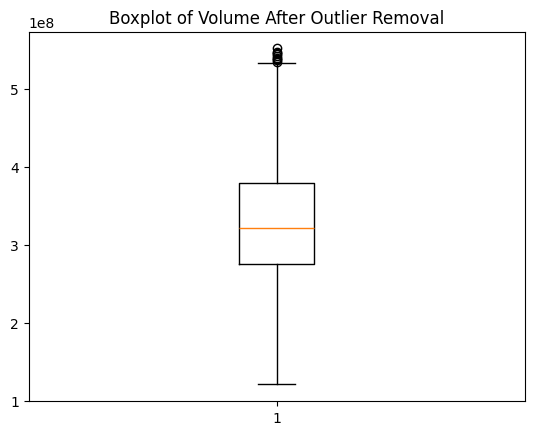

Step 2 done.


In [41]:
# === Cooray N.T.Y: Outlier Removal (IQR) ===
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

low, high = iqr_bounds(df['Volume'])
mask = (df['Volume'] >= low) & (df['Volume'] <= high)

print("Outliers removed:", (~mask).sum())
df = df[mask]

plt.boxplot(df['Volume'])
plt.title("Boxplot of Volume After Outlier Removal")
plt.show()
print("Step 2 done.")


In [42]:
# === Wicramaarachchi W C L: Normalization / Scaling ===
cols = ['Open','High','Low','Close*','Adj Close**','Volume']
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[cols])

for i, col in enumerate(cols):
    df[col + "_scaled"] = scaled[:, i]

print(df.head())
print("Step 3 done.")

                Open      High       Low    Close*  Adj Close**     Volume  \
Date                                                                         
2018-05-01  24117.29  24117.29  23808.19  24099.05     24099.05  380070000   
2018-05-02  24097.63  24185.52  23886.30  23924.98     23924.98  385350000   
2018-05-03  23836.23  23996.15  23531.31  23930.15     23930.15  389240000   
2018-05-04  23865.22  24333.35  23778.87  24262.51     24262.51  329480000   
2018-05-07  24317.66  24479.45  24263.42  24357.32     24357.32  307670000   

            Open_scaled  High_scaled  Low_scaled  Close*_scaled  \
Date                                                              
2018-05-01     0.207370     0.172171    0.193269       0.199011   
2018-05-02     0.206134     0.176571    0.198181       0.188033   
2018-05-03     0.189697     0.164358    0.175856       0.188359   
2018-05-04     0.191519     0.186106    0.191425       0.209320   
2018-05-07     0.219969     0.195529    0.221898   

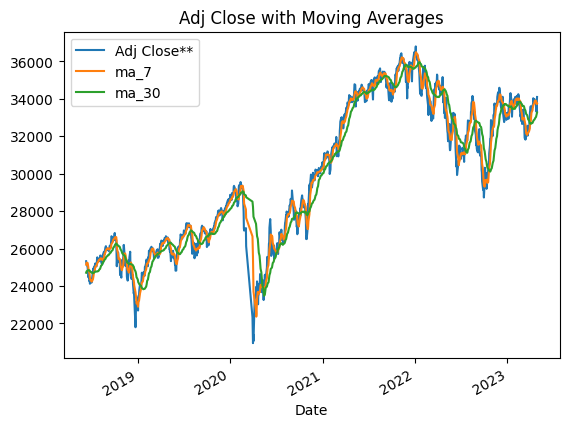

Step 4 done.


In [43]:
# === Pethvan P.P: Feature Engineering ===
df['ret_1d'] = df['Adj Close**'].pct_change()
df['ma_7'] = df['Adj Close**'].rolling(7).mean()
df['ma_30'] = df['Adj Close**'].rolling(30).mean()
df['vol_14'] = df['ret_1d'].rolling(14).std()

df = df.dropna()

df[['Adj Close**','ma_7','ma_30']].plot(title="Adj Close with Moving Averages")
plt.show()
print("Step 4 done.")

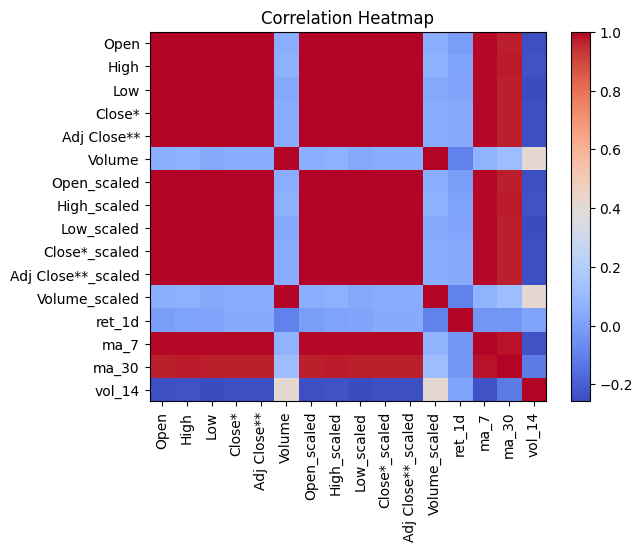

Dropped 'Close*' due to high correlation
Step 5 done.


In [44]:
# === Alagoda W.M.T.T.: Correlation & Feature Selection ===
df['ret_1d'] = df['Adj Close**'].pct_change().fillna(0)

corr = df.corr()
plt.imshow(corr.values, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

if corr.loc['Close*','Adj Close**'] > 0.98:
    df = df.drop(columns=['Close*'])
    print("Dropped 'Close*' due to high correlation")

print("Step 5 done.")

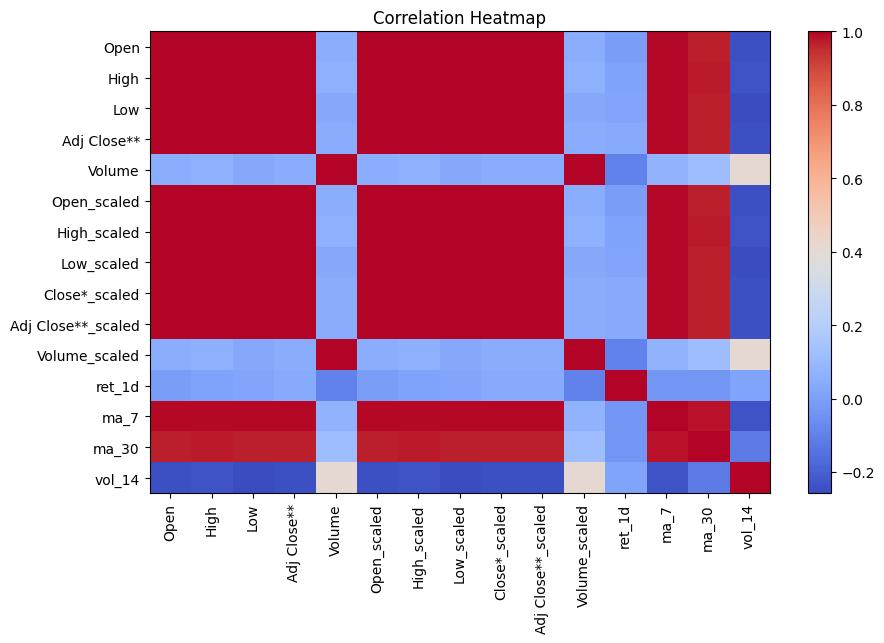

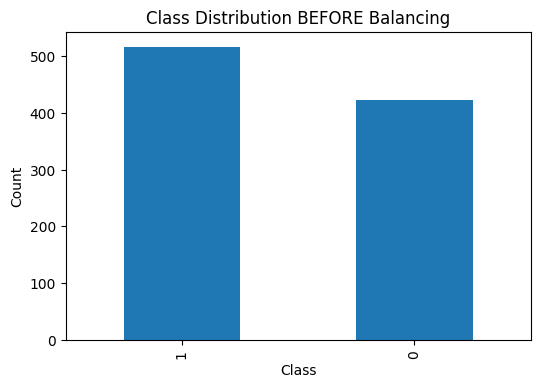

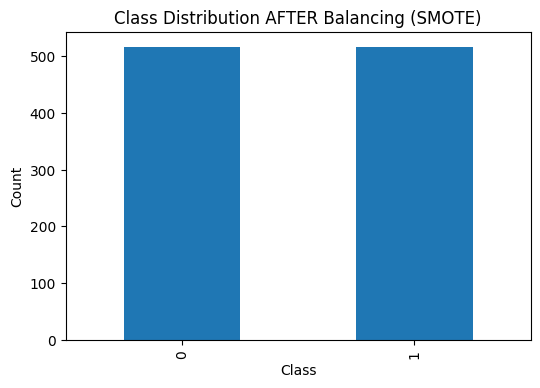

Original Training Set Class Distribution:
Target
1    517
0    422
Name: count, dtype: int64

Balanced Training Set Class Distribution:
Target
0    517
1    517
Name: count, dtype: int64
Step 6 done.


In [45]:
# === Dewmini D M I : Data Balancing ==
# Daily Returns
df['ret_1d'] = df['Adj Close**'].pct_change().fillna(0)

# Correlation Analysis
corr = df.corr()
plt.figure(figsize=(10,6))
plt.imshow(corr.values, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

# Drop highly correlated feature Close* if > 0.98 with Adj Close**
if 'Close*' in corr.index and 'Adj Close**' in corr.columns:
    if pd.notna(corr.loc['Close*', 'Adj Close**']) and corr.loc['Close*', 'Adj Close**'] > 0.98:
        df = df.drop(columns=['Close*'])
        print("Dropped 'Close*' due to high correlation with 'Adj Close**'")

# Reset Index so Date becomes column - Drop 'level_0' if it exists
if 'level_0' in df.columns:
    df = df.drop(columns=['level_0'])
df = df.reset_index()

# Create Binary Target
df['Target'] = (df['ret_1d'] > 0).astype(int)

# Features and Target
X = df.drop(columns=['Target', 'Date'])
y = df['Target']

# Train-Test Split
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Plot class distribution before balancing
plt.figure(figsize=(6,4))
y_train.value_counts().plot(kind='bar')
plt.title("Class Distribution BEFORE Balancing")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Apply SMOTE Oversampling
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Plot class distribution after balancing
plt.figure(figsize=(6,4))
y_train_bal.value_counts().plot(kind='bar')
plt.title("Class Distribution AFTER Balancing (SMOTE)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print("Original Training Set Class Distribution:")
print(y_train.value_counts())
print("\nBalanced Training Set Class Distribution:")
print(y_train_bal.value_counts())

# Create final balanced dataframe for saving
balanced_df = pd.DataFrame(X_train_bal, columns=X_train.columns)
balanced_df['Target'] = y_train_bal


print("Step 6 done.")

In [46]:
# === Save Final Processed Dataset ===
# Save preprocessed dataset as Excel
df.to_excel("processed_dataset.xlsx", index=False)
print("Preprocessed dataset saved as 'processed_dataset.xlsx'")

Preprocessed dataset saved as 'processed_dataset.xlsx'
